In [19]:
# Cell 1: Imports and load eroded inklabel image (segment 20230827161847) as BGR
import os, json, math, random
import cv2
import numpy as np
import matplotlib.pyplot as plt

SEGMENT_ID = 20230827161847
TILE_SIZE = 32  # must match config

# Training region (see dataloader.py for segment 20230827161847)
TRAIN_Y_START, TRAIN_Y_END = 200, 5600
TRAIN_X_START, TRAIN_X_END = 1000, 4600

label_path = f"./eroded_inklabels/{SEGMENT_ID}.png"
if not os.path.exists(label_path):
    raise FileNotFoundError(f"Label file not found: {label_path}")
label_gray = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
if label_gray is None:
    raise RuntimeError("Failed to load label image.")
label_bgr = cv2.cvtColor(label_gray, cv2.COLOR_GRAY2BGR)

# Crop to training region so that mined tile coordinates align after offset subtraction
label_bgr = label_bgr[TRAIN_Y_START:TRAIN_Y_END, TRAIN_X_START:TRAIN_X_END]
print("Cropped Label shape:", label_bgr.shape)

Cropped Label shape: (5400, 3600, 3)


In [20]:
# Cell 2: Read hard mining JSONL file & group by z
jsonl_path = "hard_negs/hard_mining_epoch_19.jsonl"
hard_negatives = []  # (z grouped later)
hard_positives = []
by_z = {}  # z -> {neg:[], pos:[]}
meta = {}
print("Reading:", jsonl_path)
if not os.path.exists(jsonl_path):
    raise FileNotFoundError(f"Mining file not found: {jsonl_path}")
with open(jsonl_path, 'r') as f:
    for line in f:
        line=line.strip()
        if not line: continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        if obj.get('_type') == 'meta':
            meta = obj; continue
        z = obj.get('z')
        lbl = obj.get('label')
        if z is None or lbl not in (0,1):
            continue
        if z not in by_z:
            by_z[z] = {'neg':[], 'pos':[]}
        if lbl == 0:
            by_z[z]['neg'].append(obj); hard_negatives.append(obj)
        else:
            by_z[z]['pos'].append(obj); hard_positives.append(obj)
print(f"Loaded total: {len(hard_negatives)} hard negatives, {len(hard_positives)} hard positives across {len(by_z)} z layers")
if meta: print("Meta:", meta)
sorted_z = sorted(by_z.keys())
print("Z layers:", sorted_z)

Reading: hard_negs/hard_mining_epoch_19.jsonl
Loaded total: 1678 hard negatives, 385 hard positives across 4 z layers
Meta: {'_type': 'meta', 'hard_negatives': 1678, 'hard_positives': 385}
Z layers: [28, 32, 36, 40]


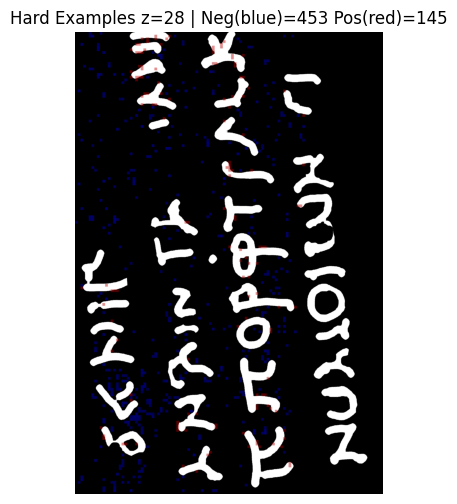

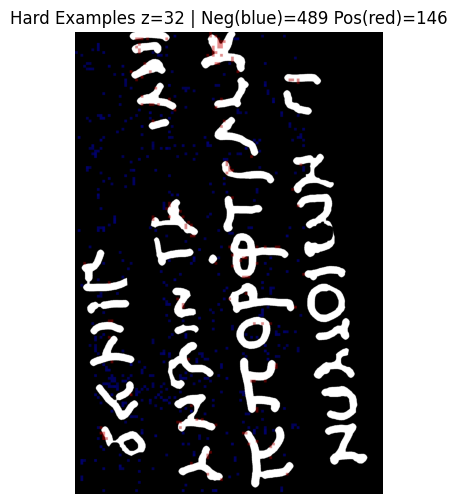

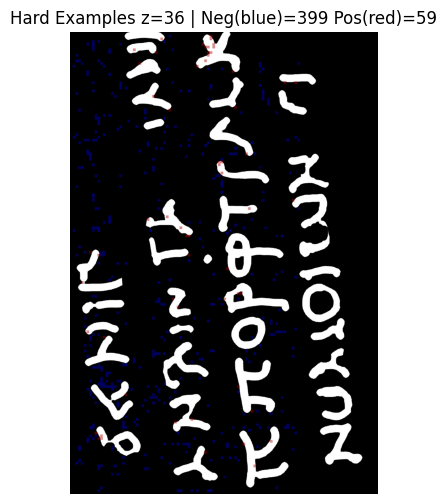

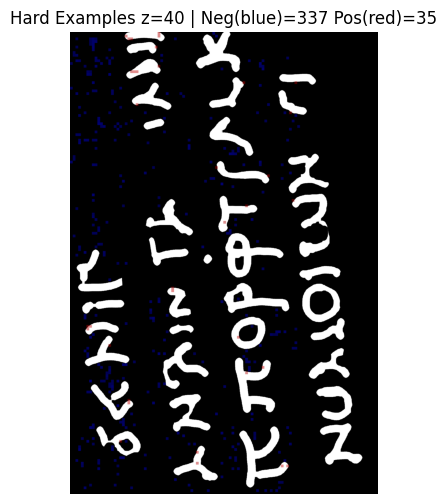

In [21]:
# Cell 3: Per-Z visualization
# Blue = hard negatives (intensity = score), Red = hard positives (intensity = 1 - score)

def draw_tile(img, x, y, color, alpha=0.45):
    h, w = img.shape[:2]
    if x >= w or y >= h: return
    x2 = min(x+TILE_SIZE, w); y2 = min(y+TILE_SIZE, h)
    roi = img[y:y2, x:x2]
    color_arr = np.zeros_like(roi); color_arr[:] = color
    cv2.addWeighted(color_arr, alpha, roi, 1-alpha, 0, dst=roi)

for z in sorted_z:
    neg = by_z[z]['neg']
    pos = by_z[z]['pos']
    overlay = label_bgr.copy()
    # Negatives (blue)
    for rec in neg:
        xg, yg = rec['x'], rec['y']
        # shift into cropped space
        x = xg - TRAIN_X_START; y = yg - TRAIN_Y_START
        if x < 0 or y < 0: continue
        s = float(rec['score']); intensity = max(0.0, min(1.0, s))
        b = int(255 * intensity); draw_tile(overlay, x, y, (b,0,0))
    # Positives (red)
    for rec in pos:
        xg, yg = rec['x'], rec['y']
        x = xg - TRAIN_X_START; y = yg - TRAIN_Y_START
        if x < 0 or y < 0: continue
        s = float(rec['score']); intensity = max(0.0, min(1.0, 1.0 - s))
        r = int(255 * intensity); draw_tile(overlay, x, y, (0,0,r))
    plt.figure(figsize=(4,6))
    plt.title(f"Hard Examples z={z} | Neg(blue)={len(neg)} Pos(red)={len(pos)}")
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis('off')
plt.show()

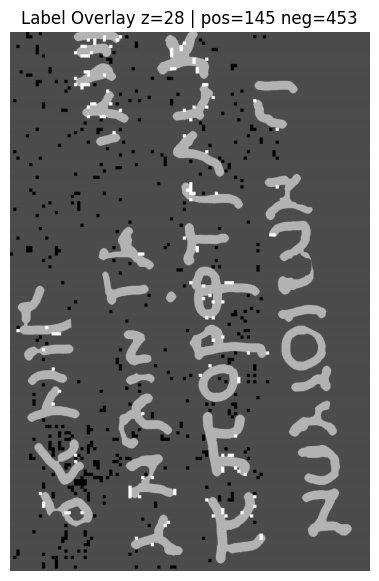

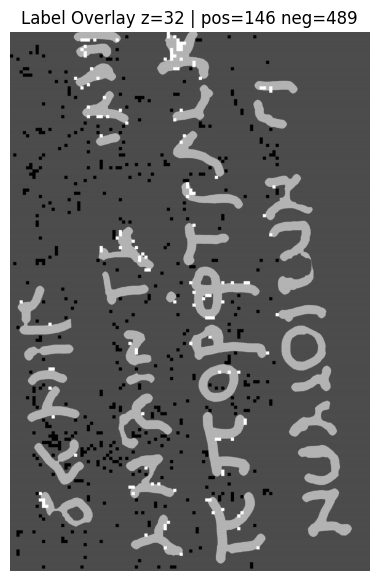

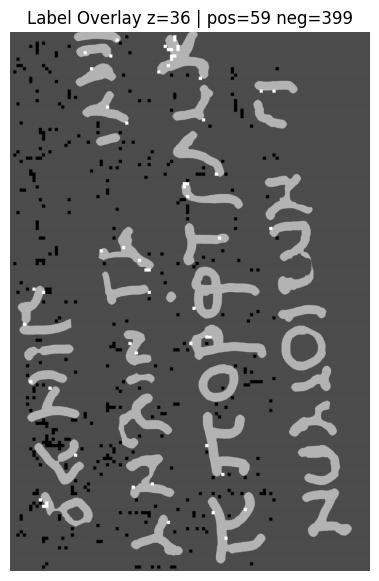

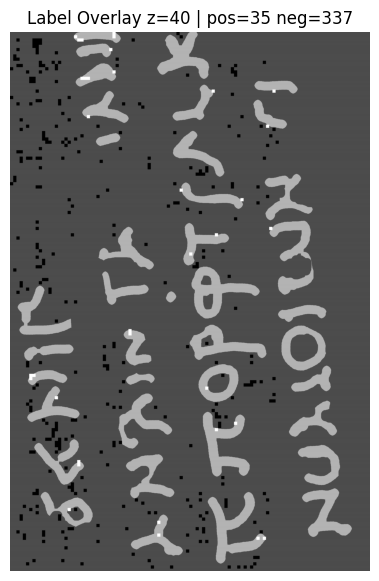

In [22]:
# Per-depth label visualization: base inklabels + mined tile labels per z
# Base mapping: ink=0.7, background=0.3; tile label 1 -> 1.0, label 0 -> 0.0
cropped_gray = label_gray[TRAIN_Y_START:TRAIN_Y_END, TRAIN_X_START:TRAIN_X_END]
base_bin = (cropped_gray > 0).astype(np.float32)

def apply_tile(arr, x, y, val):
    if x < 0 or y < 0: return
    h, w = arr.shape
    if x >= w or y >= h: return
    arr[y:y+TILE_SIZE, x:x+TILE_SIZE] = val

for z in sorted_z:
    vis = np.where(base_bin == 1, 0.7, 0.3).astype(np.float32)
    neg_ct = 0; pos_ct = 0
    recs = by_z[z]['neg'] + by_z[z]['pos']
    for rec in recs:
        x = rec['x'] - TRAIN_X_START
        y = rec['y'] - TRAIN_Y_START
        lbl = rec.get('label', 0)
        if lbl == 1:
            apply_tile(vis, x, y, 1.0); pos_ct += 1
        else:
            apply_tile(vis, x, y, 0.0); neg_ct += 1
    plt.figure(figsize=(5,7))
    plt.title(f"Label Overlay z={z} | pos={pos_ct} neg={neg_ct}")
    plt.imshow(vis, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
plt.show()